# FIG_5 — ASWIFT FIG_5 style reformat (corrected normalization)

This version fixes the signal and SNR calculation so they follow the FIG_5 logic.

Signal/SNR logic used here:
- use the single selected signal trace column for each method: `signal-{freq}hz-ch{channel}-{method}`
- optionally clip to `start_time_min`, then normalize as `s / mean(s[:5])` from the clipped data
- split the normalized trace into consecutive 5-sample blocks
- Column 2 plots block mean ± SD

Updates in this version:
- time is plotted in minutes
- `start_time_min` clips early data before normalization/statistics
- ch0/ch1 first-column labels are explicitly Blood/ISF
- first-column raw traces use optional median-MAD outlier filtering via `trace_current_mad_cutoff`


/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_14528/1109036586.py:424: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(trace_cmap)
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_14528/1109036586.py:424: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(trace_cmap)


Saved to: /Users/Max_1/PycharmProjects/aswift_figures/figures/figure_exports


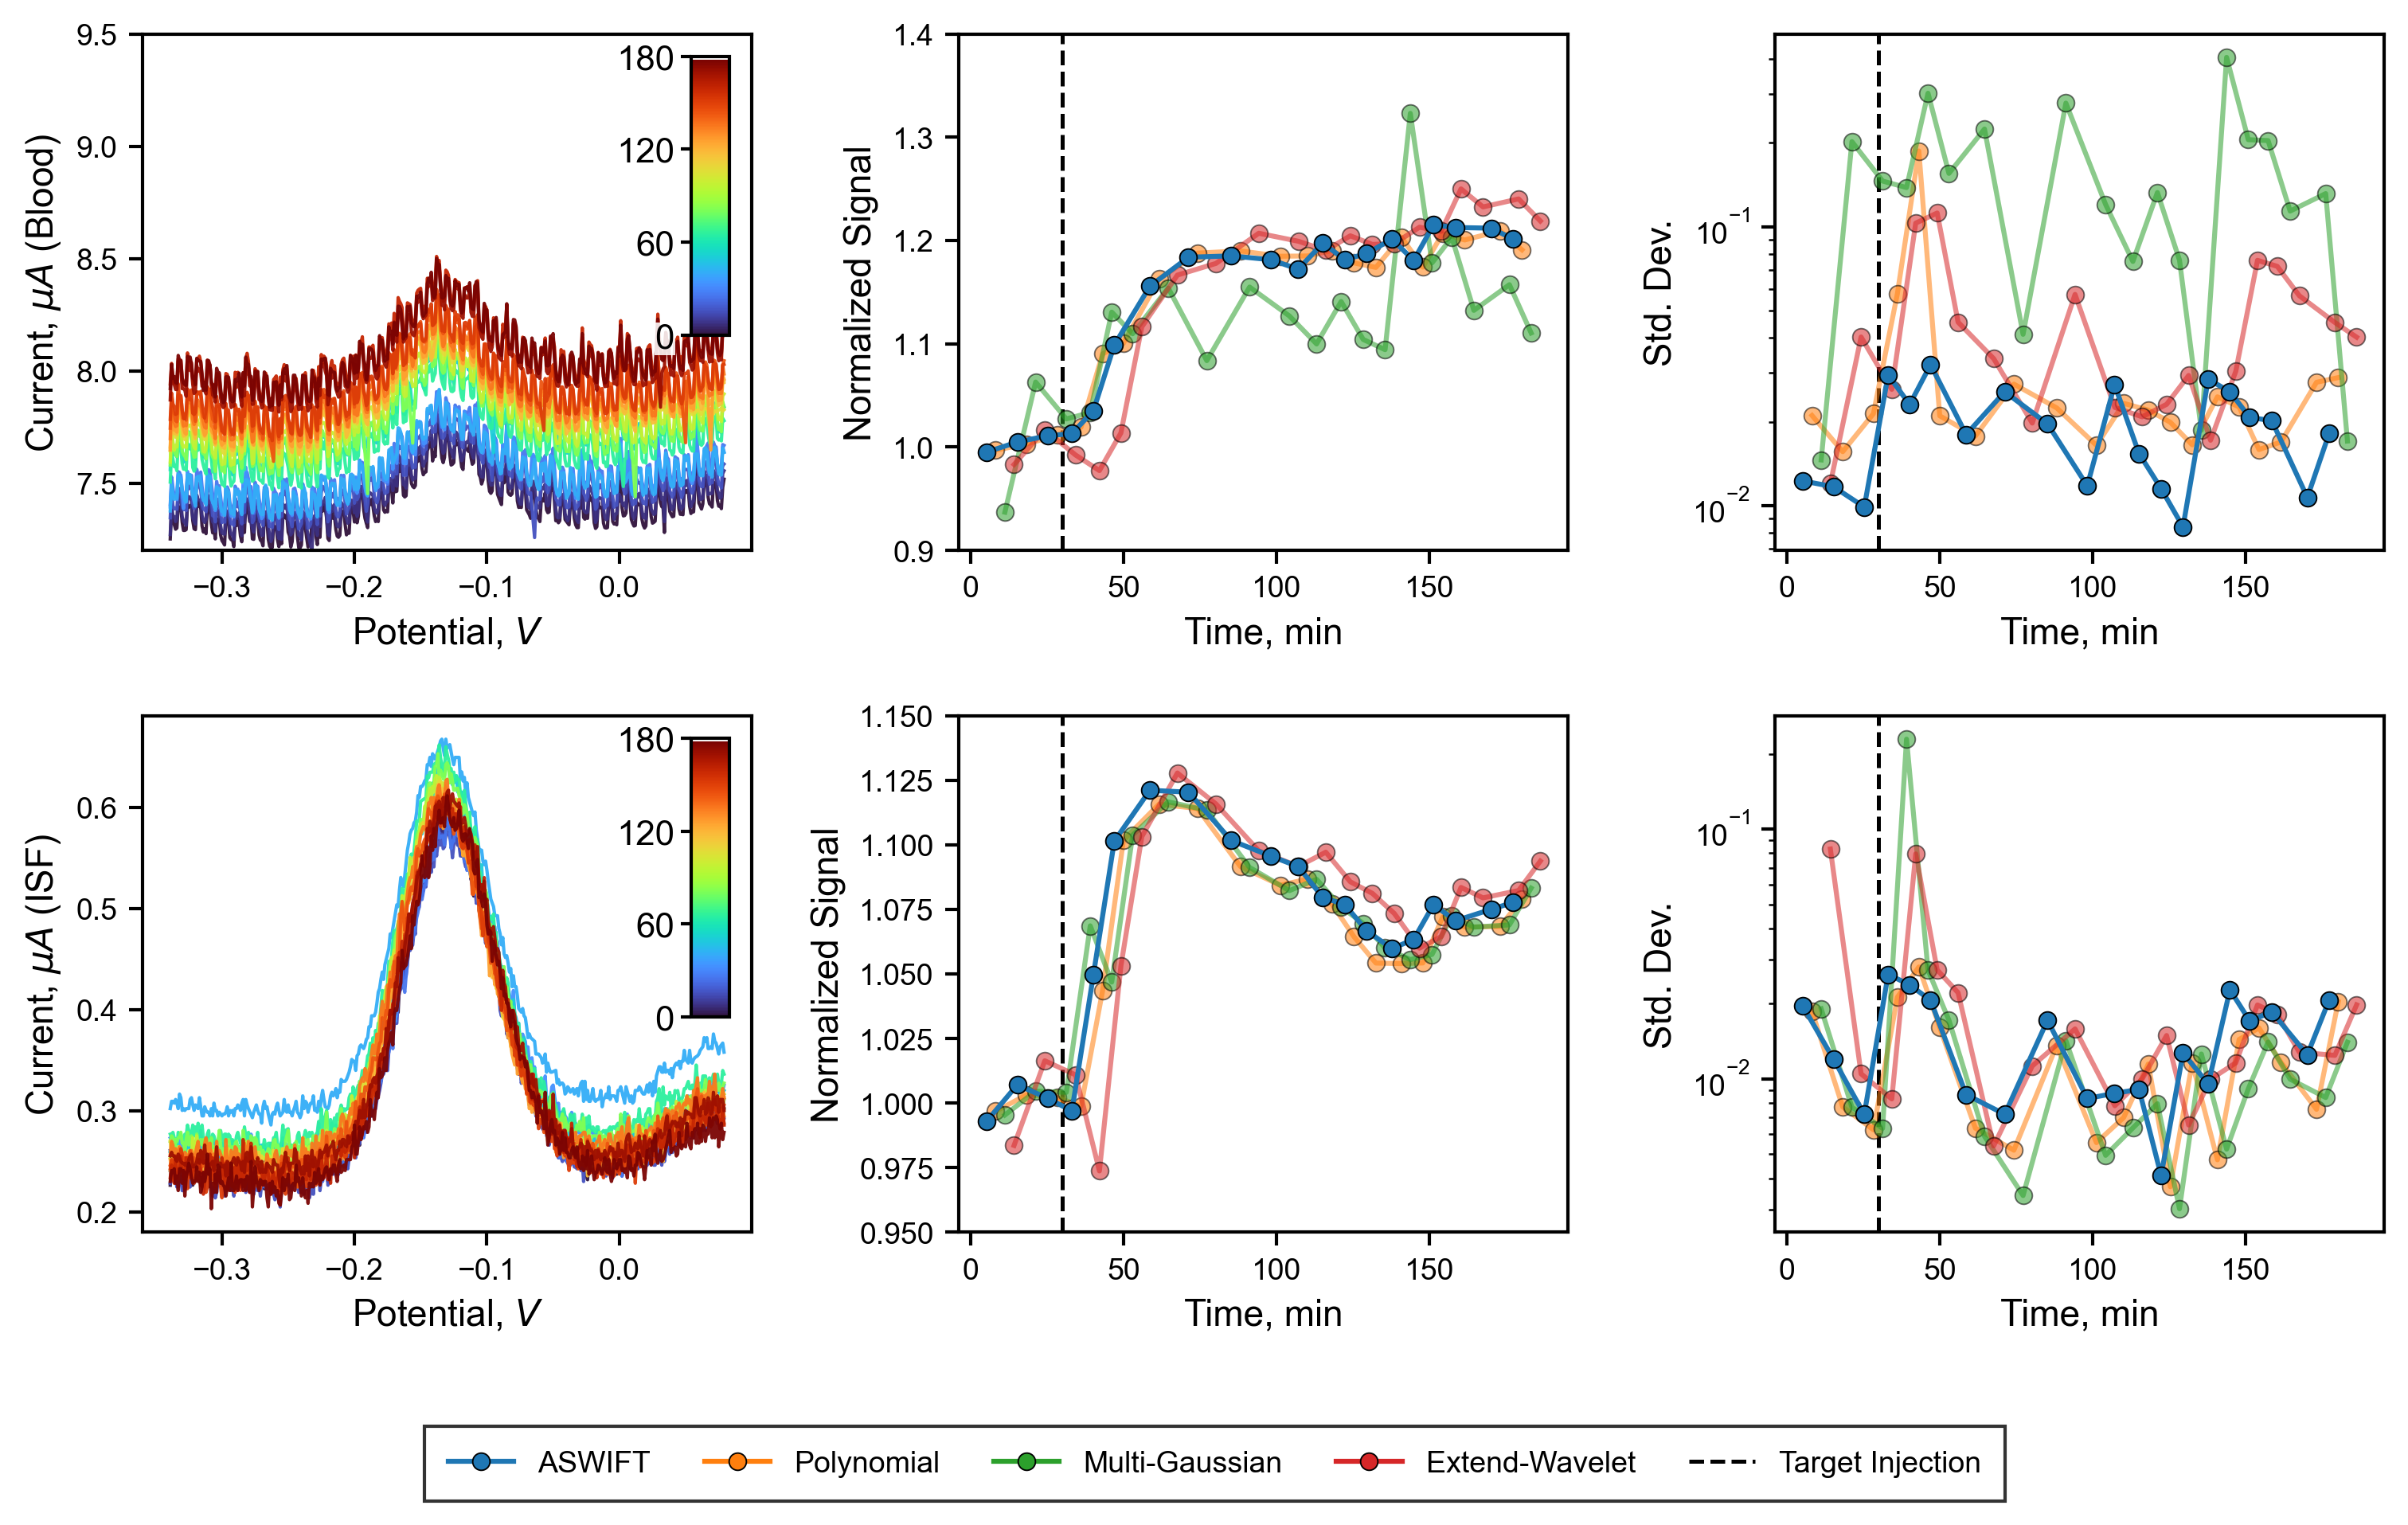

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Mapping, Sequence
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm, Normalize
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from peak_extraction.extract_peaks import mask_multichannel_outliers

# -----------------------------
# ASWIFT-friendly plotting defaults
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.default": "it",
})


def lighten_color(color, amount=0.68):
    import matplotlib.colors as mc
    c = np.array(mc.to_rgb(color))
    return tuple((1 - amount) * c + amount * np.ones(3))


def save_figure_multi(fig, stem, out_dir="figure_exports"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{stem}.png", transparent=True)
    fig.savefig(out_dir / f"{stem}.pdf", transparent=True)
    fig.savefig(out_dir / f"{stem}.svg", transparent=True)
    print(f"Saved to: {out_dir.resolve()}")


def _hour_tick_label(x: float) -> str:
    x = float(x)
    if not np.isfinite(x):
        return ""
    if abs(x) >= 100:
        return f"{x:.0f}"
    if abs(x) >= 10:
        return f"{x:.1f}".rstrip("0").rstrip(".")
    return f"{x:.2f}".rstrip("0").rstrip(".")


def _select_colorbar_ticks(values, max_ticks: int = 4) -> np.ndarray:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return np.array([], dtype=float)
    finite = np.unique(np.sort(finite))
    if finite.size <= max_ticks:
        return finite
    idx = np.linspace(0, finite.size - 1, max_ticks)
    idx = np.unique(np.round(idx).astype(int))
    return finite[idx]



def _add_inset_colorbar(
    fig,
    ax,
    mappable,
    title="Time (min)",
    tick_values=None,
    tick_labels=None,
    *,
    width="6.2%",          # larger colorbar thickness
    height="54%",          # larger colorbar length
    loc="upper right",
    borderpad=0.75,        # smaller = closer to the corner / more over the data
    tick_fontsize=10.5,    # tick-label font size
    title_fontsize=10.8,   # colorbar title font size
    tick_width=1.0,
    tick_length=3.2,
    tick_pad=2.0,
    title_pad=6.0,
    title_x=0.5,
    title_ha="center",
    facecolor="white",
    face_alpha=0.88,
    zorder=1000,
):
    """Inset colorbar drawn above the data with a light text/background mask."""
    cax = inset_axes(
        ax,
        width=width,
        height=height,
        loc=loc,
        borderpad=borderpad,
    )
    cax.set_zorder(zorder)
    cax.set_facecolor(facecolor)
    cax.patch.set_alpha(face_alpha)

    cbar = fig.colorbar(mappable, cax=cax)
    cbar.ax.set_zorder(zorder + 1)
    cbar.ax.set_facecolor(facecolor)
    cbar.ax.patch.set_alpha(face_alpha)
    cbar.ax.yaxis.set_ticks_position("left")
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.tick_params(labelsize=tick_fontsize, width=tick_width, length=tick_length, pad=tick_pad)
    cbar.ax.set_title(title, fontsize=title_fontsize, pad=title_pad, x=title_x, ha=title_ha)

    if tick_values is not None and len(tick_values):
        cbar.set_ticks(tick_values)
        if tick_labels is None:
            cbar.set_ticklabels([_hour_tick_label(t) for t in tick_values])
        else:
            cbar.set_ticklabels([str(t) for t in tick_labels])

    for txt in list(cbar.ax.get_yticklabels()) + [cbar.ax.title]:
        txt.set_bbox(dict(facecolor=facecolor, alpha=face_alpha, edgecolor="none", pad=0.25))

    if hasattr(cbar, "solids") and cbar.solids is not None:
        cbar.solids.set_alpha(1.0)
    cbar.outline.set_linewidth(tick_width)
    return cbar


METHODS = {
    "aswift": "ASWIFT",
    "poly_linear": "Polynomial",
    "plaxco_gauss": "Multi-Gaussian",
    "justine_ewd": "Extend-Wavelet",
}

METHOD_STYLE = {
    "aswift": {
        "color": "#1f77b4",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "zorder": 20.0,
    },
    "poly_linear": {
        "color": "#ff7f0e",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "zorder": 3.0,
    },
    "plaxco_gauss": {
        "color": "#2ca02c",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "zorder": 3.0,
    },
    "justine_ewd": {
        "color": "#d62728",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "zorder": 3.0,
    },

}


def _method_offsets(values: Sequence[float] | np.ndarray | None, methods: Mapping[str, str]) -> dict[str, float]:
    """Return per-method plotting offsets, preserving method order."""
    if values is None:
        return {method: 0.0 for method in methods}
    vals = np.asarray(values, dtype=float).ravel()
    if vals.size != len(methods):
        raise ValueError(
            f"Expected {len(methods)} method offsets, but got {vals.size}."
        )
    return {method: float(offset) for method, offset in zip(methods.keys(), vals)}


def _plot_order_with_aswift_last(methods: Mapping[str, str]) -> list[str]:
    """Plot non-ASWIFT methods first and ASWIFT last so ASWIFT remains visually on top."""
    order = [method for method in methods if method != "aswift"]
    if "aswift" in methods:
        order.append("aswift")
    return order


def _coerce_exclude_indices(exclude_indices: Sequence[int] | np.ndarray | None) -> np.ndarray:
    """Return sorted, unique, non-negative positional row indices to exclude."""
    if exclude_indices is None:
        return np.array([], dtype=int)
    idx = np.asarray(exclude_indices, dtype=int).ravel()
    idx = idx[idx >= 0]
    return np.unique(idx)


def _drop_excluded_rows(df: pd.DataFrame, exclude_indices: Sequence[int] | np.ndarray | None) -> pd.DataFrame:
    """Drop rows by zero-based positional index, not by the DataFrame's existing index labels."""
    idx = _coerce_exclude_indices(exclude_indices)
    if idx.size == 0:
        return df.reset_index(drop=True)
    keep = np.ones(len(df), dtype=bool)
    idx = idx[idx < len(df)]
    keep[idx] = False
    return df.iloc[keep].reset_index(drop=True)

def _time_values_to_minutes(time_values: Sequence[float] | np.ndarray, *, time_unit: str = "hours") -> np.ndarray:
    """Convert the selected time column to minutes for plotting, clipping, and normalization."""
    t = np.asarray(time_values, dtype=float)
    unit = str(time_unit).strip().lower()
    if unit in {"h", "hr", "hrs", "hour", "hours"}:
        return 60.0 * t
    if unit in {"m", "min", "mins", "minute", "minutes"}:
        return t
    if unit in {"s", "sec", "secs", "second", "seconds"}:
        return t / 60.0
    raise ValueError("time_unit must be 'hours', 'minutes', or 'seconds'.")


def _filter_start_time(
    time_min: np.ndarray,
    *arrays: np.ndarray,
    start_time_min: float | None = None,
):
    """Apply the same start-time clip to time and any aligned arrays."""
    keep = np.isfinite(time_min)
    if start_time_min is not None:
        keep &= time_min >= float(start_time_min)
    out = [time_min[keep]]
    out.extend(np.asarray(a)[keep] for a in arrays)
    return out


def read_voltammogram_csv_all(csv_path: str | Path):
    csv_path = Path(csv_path)
    df = (
        pd.read_csv(csv_path, skiprows=6, encoding="utf-16")
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
    )
    volts = df.iloc[:, 0].astype(float).to_numpy()
    currents = df.iloc[:, 1::2].dropna(how="all").astype(float).to_numpy().T
    return volts, currents


def read_voltammogram_csv(csv_path: str | Path, channel: int = 0):
    volts, currents = read_voltammogram_csv_all(csv_path)
    return volts, currents[channel]


def _infer_time_column(df: pd.DataFrame, candidates: Sequence[str] | None = None) -> str:
    if candidates is None:
        candidates = (
            "time_h",
            "time_hr",
            "time_hours",
            "hours",
            "hour",
            "elapsed_hours",
            "time",
        )
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise KeyError(
        "Could not find a time column in the results table. "
        f"Tried: {list(candidates)}\nAvailable columns:\n{list(df.columns)}"
    )


def _get_signal_series(df: pd.DataFrame, *, freq_hz: int, channel: int, method: str) -> np.ndarray:
    col = f"signal-{freq_hz}hz-ch{channel}-{method}"
    if col not in df.columns:
        raise KeyError(f"Missing column '{col}'")
    return df[col].to_numpy(dtype=float)


def _normalize_like_original(signal: np.ndarray, baseline_n: int = 5) -> np.ndarray:
    """
    Match the FIG_5 logic:
      s = signal[np.isfinite(signal)]
      s = s / mean(s[:5])

    We then return a finite-only normalized trace for block statistics.
    """
    s = np.asarray(signal, float)
    s = s[np.isfinite(s)]
    if len(s) < baseline_n:
        raise ValueError(f"Need at least {baseline_n} finite points for normalization, got {len(s)}")
    b = np.mean(s[:baseline_n])
    if baseline_n == 0:
        b = 1
    return s / b


def _block_reduce(x: np.ndarray, block_size: int = 5):
    n_blocks = len(x) // block_size
    if n_blocks <= 0:
        raise ValueError("No complete blocks available for the requested block size.")
    trimmed = x[: n_blocks * block_size]
    blocks = trimmed.reshape(n_blocks, block_size)
    means = np.mean(blocks, axis=1)
    stds = np.std(blocks, axis=1, ddof=1)
    return means, stds, blocks


def _block_time_from_df(time_values: np.ndarray, block_size: int = 5) -> np.ndarray:
    t = np.asarray(time_values, float)
    t = t[np.isfinite(t)]
    n_blocks = len(t) // block_size
    if n_blocks <= 0:
        raise ValueError("No complete time blocks available.")
    trimmed = t[: n_blocks * block_size]
    return trimmed.reshape(n_blocks, block_size).mean(axis=1)


def _find_trace_files(folder: str | Path, freq_hz: int, ch01_folder: str | None = "CH01"):
    folder = Path(folder)
    search_dirs = []
    if ch01_folder is not None:
        search_dirs.append(folder / ch01_folder)
    search_dirs.append(folder)

    files = []
    pat = re.compile(rf"^{freq_hz}hz-(\d+)\.csv$", re.IGNORECASE)
    for d in search_dirs:
        if not d.exists():
            continue
        for f in d.glob(f"{freq_hz}hz-*.csv"):
            m = pat.match(f.name)
            if m:
                files.append((int(m.group(1)), f))
    files = sorted(set(files), key=lambda x: x[0])
    return files


def _plot_time_trace_panel(
    ax,
    *,
    folder: str | Path,
    freq_hz: int,
    time_min: np.ndarray | None,
    fig=None,
    add_time_colorbar: bool = True,
    colorbar_title: str = "Time (min)",
    colorbar_n_ticks: int = 4,
    colorbar_tick_values: Sequence[float] | None = None,
    colorbar_tick_labels: Sequence[str] | None = None,
    ch01_folder: str | None = "CH01",
    channel: int = 0,
    medium_label: str | None = None,
    exclude_indices: Sequence[int] | np.ndarray | None = None,
    start_time_min: float | None = None,
    trace_cmap: str = "turbo",
    trace_log_color: bool = False,
    trace_every_n: int = 12,
    trace_outlier_kwargs: dict | None = None,
):
    trace_files = _find_trace_files(folder, freq_hz=freq_hz, ch01_folder=ch01_folder)
    excluded = set(_coerce_exclude_indices(exclude_indices).tolist())

    trace_file_lookup = dict(trace_files)

    filtered_trace_files = []
    filtered_trace_times = []
    time_arr = None if time_min is None else np.asarray(time_min, dtype=float)

    for n, f in trace_files:
        row_idx = n - 1

        # If this trace is excluded, use the next trace file instead.
        # Keep stepping forward until the replacement trace is not excluded.
        while row_idx in excluded:
            n += 1
            row_idx = n - 1

            if n not in trace_file_lookup:
                f = None
                break

            f = trace_file_lookup[n]

        if f is None:
            continue

        if time_arr is not None and row_idx < len(time_arr):
            t = float(time_arr[row_idx])
            if not np.isfinite(t):
                continue
            if start_time_min is not None and t < float(start_time_min):
                continue
        else:
            t = float(n)

        filtered_trace_files.append((n, f))
        filtered_trace_times.append(t)

    trace_files = filtered_trace_files[::trace_every_n]
    trace_time_min = np.asarray(filtered_trace_times[::trace_every_n], dtype=float)
    if len(trace_files) == 0:
        raise FileNotFoundError(f"No trace files found after filtering for {freq_hz} Hz in {folder}.")

    cmap = cm.get_cmap(trace_cmap)
    positive = trace_time_min[trace_time_min > 0]
    if trace_log_color and len(positive):
        norm = LogNorm(vmin=float(np.nanmin(positive)), vmax=float(np.nanmax(positive)))
    elif np.nanmax(trace_time_min) > np.nanmin(trace_time_min):
        norm = Normalize(vmin=float(np.nanmin(trace_time_min)), vmax=float(np.nanmax(trace_time_min)))
    else:
        norm = Normalize(vmin=0.0, vmax=1.0)

    for (_, fpath), t in zip(trace_files, trace_time_min):
        v, all_currents = read_voltammogram_csv_all(fpath)
        if trace_outlier_kwargs is not None:
            v, all_currents = mask_multichannel_outliers(v, all_currents, **trace_outlier_kwargs)
        i = all_currents[channel]
        keep = np.isfinite(v) & np.isfinite(i)
        color_val = float(t)
        if isinstance(norm, LogNorm) and color_val <= 0:
            color_val = float(norm.vmin)
        ax.plot(v[keep], i[keep], color=cmap(norm(color_val)), linewidth=1.0, alpha=0.95)

    if fig is not None and add_time_colorbar:
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        tick_values = colorbar_tick_values
        if tick_values is None:
            tick_values = _select_colorbar_ticks(trace_time_min, max_ticks=colorbar_n_ticks)
        _add_inset_colorbar(
            fig, ax, sm, title=colorbar_title, tick_values=tick_values, tick_labels=colorbar_tick_labels
        )

    if medium_label is None:
        medium_label = "Blood" if channel == 0 else "ISF" if channel == 1 else f"ch{channel}"

    ax.set_xlabel(r"Potential, $V$")
    ax.set_ylabel(fr"Current, $\mu A$ ({medium_label})")

def _compute_stats_like_original(
    df: pd.DataFrame,
    *,
    freq_hz: int,
    channel: int,
    methods: Mapping[str, str],
    block_size: int = 5,
    baseline_n: int = 5,
    time_column: str = "time",
    time_unit: str = "hours",
    exclude_indices: Sequence[int] | np.ndarray | None = None,
    start_time_min: float | None = None,
):
    df = _drop_excluded_rows(df, exclude_indices)
    time_min_all = _time_values_to_minutes(df[time_column].to_numpy(float), time_unit=time_unit)

    stats = {}
    for method in methods:
        s_all = _get_signal_series(df, freq_hz=freq_hz, channel=channel, method=method)

        # Keep time and signal aligned after finite filtering. The start-time clip is applied
        # before normalization, so the baseline is calculated from the first points after the clip.
        keep = np.isfinite(time_min_all) & np.isfinite(s_all)
        time_min, s = _filter_start_time(time_min_all[keep], s_all[keep], start_time_min=start_time_min)
        if len(s) < baseline_n:
            raise ValueError(
                f"Need at least {baseline_n} finite, non-excluded points after start_time_min "
                f"for normalization of {method} ch{channel}; got {len(s)}."
            )
        baseline = 1.0 if baseline_n == 0 else float(np.mean(s[:baseline_n]))
        if not np.isfinite(baseline) or baseline == 0:
            raise ValueError(
                f"Invalid normalization baseline for {method} ch{channel}: {baseline}."
            )
        s_norm = s / baseline

        means, stds, blocks = _block_reduce(s_norm, block_size=block_size)
        block_time_min = _block_time_from_df(time_min, block_size=block_size)
        n = min(len(block_time_min), len(means))
        stats[method] = {
            "time_min": block_time_min[:n],
            "mean": means[:n],
            "std": stds[:n],
        }
    return stats

def _plot_signal_row(
    ax_sig,
    *,
    stats: dict,
    methods: Mapping[str, str],
    target_injection_min: float | None = None,
    uncertainty_alpha: float = 0.35,
    errorbar_alpha: float = 0.65,
    ylim: tuple[float, float] | None = None,
    show_uncertainty: bool = True,
    method_time_offsets_min: Sequence[float] | np.ndarray | None = None,
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
):
    if target_injection_min is not None:
        ax_sig.axvline(
            target_injection_min,
            color="black",
            linestyle="--",
            linewidth=1.2,
            zorder=0,
        )

    offsets = _method_offsets(method_time_offsets_min, methods)

    for method in _plot_order_with_aswift_last(methods):
        st = METHOD_STYLE[method]
        color = st["color"]
        alpha = aswift_alpha if method == "aswift" else other_methods_alpha
        zorder = st["zorder"]
        lighter = lighten_color(color, amount=0.68)
        t = stats[method]["time_min"] + offsets[method]
        y = stats[method]["mean"]
        yerr = stats[method]["std"]
        keep_sig = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr)

        if show_uncertainty:
            ax_sig.fill_between(
                t[keep_sig],
                (y - 0.70 * yerr)[keep_sig],
                (y + 0.70 * yerr)[keep_sig],
                color=lighter,
                alpha=uncertainty_alpha * alpha,
                linewidth=0,
                zorder=zorder - 1,
            )
            ax_sig.errorbar(
                t[keep_sig],
                y[keep_sig],
                yerr=yerr[keep_sig],
                fmt="none",
                ecolor=lighter,
                alpha=errorbar_alpha * alpha,
                elinewidth=1.1,
                capsize=2.3,
                capthick=1.0,
                zorder=zorder,
            )
        ax_sig.plot(
            t[keep_sig], y[keep_sig],
            color=color,
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker=st["marker"],
            markersize=st["markersize"],
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.45,
            alpha=alpha,
            zorder=zorder + 1,
        )

    if ylim is not None:
        ax_sig.set_ylim(*ylim)
    ax_sig.set_ylabel("Normalized Signal")
    ax_sig.set_xlabel("Time, min")


def _plot_method_std_row(
    ax_std,
    *,
    stats: dict,
    methods: Mapping[str, str],
    target_injection_min: float | None = None,
    log_scale: bool = False,
    ylim: tuple[float, float] | None = None,
    method_time_offsets_min: Sequence[float] | np.ndarray | None = None,
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
):
    if target_injection_min is not None:
        ax_std.axvline(
            target_injection_min,
            color="black",
            linestyle="--",
            linewidth=1.2,
            zorder=0,
        )

    offsets = _method_offsets(method_time_offsets_min, methods)

    for method in _plot_order_with_aswift_last(methods):
        st = METHOD_STYLE[method]
        color = st["color"]
        alpha = aswift_alpha if method == "aswift" else other_methods_alpha
        zorder = st["zorder"]
        t = stats[method]["time_min"] + offsets[method]
        y = stats[method]["std"]
        keep_std = np.isfinite(t) & np.isfinite(y)
        if log_scale:
            keep_std &= y > 0

        ax_std.plot(
            t[keep_std], y[keep_std],
            color=color,
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker=st["marker"],
            markersize=st["markersize"],
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.45,
            alpha=alpha,
            zorder=zorder + 1,
        )

    if log_scale:
        ax_std.set_yscale("log")
    if ylim is not None:
        ax_std.set_ylim(*ylim)
    ax_std.set_ylabel("Std. Dev.")
    ax_std.set_xlabel("Time, min")

def plot_fig_5_style(
    datasets: Sequence[dict],
    *,
    methods_csv_file: str | Path | None = None,
    methods: Mapping[str, str] = METHODS,
    freq_hz: int = 50,
    block_size: int = 5,
    baseline_n: int = 5,
    exclude_indices: Sequence[int] | np.ndarray | None = None,
    time_column_candidates: Sequence[str] = (
        "time_min", "time_minutes", "minutes", "min",
        "time_h", "time_hr", "time_hours", "hours", "hour", "elapsed_hours", "time"
    ),
    ch01_folder: str | None = "CH01",
    time_unit: str = "hours",
    start_time_min: float | None = None,
    trace_outlier_kwargs: dict | None = None,
    trace_cmap: str = "turbo",
    trace_log_color: bool = False,
    save_stem: str | None = None,
    target_injection_min: float | None = 96.0,
    target_injection_label: str = "Target Injection",
    uncertainty_alpha: float = 0.35,
    errorbar_alpha: float = 0.65,
    col1_ylims: Sequence[tuple[float, float] | None] | None = None,
    col2_ylims: Sequence[tuple[float, float] | None] | None = None,
    plot_std_column: bool = False,
    std_log_scale: bool = False,
    col3_ylims: Sequence[tuple[float, float] | None] | None = None,
    time_colorbar_tick_values: Sequence[float] | None = (0, 60, 120, 180),
    time_colorbar_tick_labels: Sequence[str] | None = None,
    method_time_offsets_min: Sequence[float] | np.ndarray | None = (-1.2, -0.4, 0.4, 1.2),
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
):
    """
    Plot FIG_5 from one methods CSV.

    Expected methods CSV columns include one signal column per method/channel, e.g.
        signal-50hz-ch0-aswift  # Blood
        signal-50hz-ch1-aswift  # ISF

    `exclude_indices` is a zero-based positional index array. Those rows are removed before
    normalization, block averaging, block SD calculation, and signal plotting. Raw trace files
    with acquisition number N are also skipped when N - 1 is in `exclude_indices`.

    `start_time_min` clips away early rows/traces before normalization, so the baseline is
    calculated from the first `baseline_n` points at or after `start_time_min`.

    If `plot_std_column=True`, column 2 shows only the normalized method means, with
    no shaded uncertainty or error bars, and a third column shows each method's block
    standard deviation. Use `std_log_scale=True` for a log-scaled SD axis, and set
    `col3_ylims` to control the top and bottom SD-axis limits.
    """
    if len(datasets) != 2:
        raise ValueError("Pass exactly two datasets, typically Blood/ch0 and ISF/ch1.")
    if col1_ylims is None:
        col1_ylims = [None, None]
    if len(col1_ylims) != len(datasets):
        raise ValueError("col1_ylims must have one entry per dataset row.")
    if col2_ylims is None:
        col2_ylims = [None, None]
    if len(col2_ylims) != len(datasets):
        raise ValueError("col2_ylims must have one entry per dataset row.")
    if col3_ylims is None:
        col3_ylims = [None, None]
    if len(col3_ylims) != len(datasets):
        raise ValueError("col3_ylims must have one entry per dataset row.")

    shared_df = None
    if methods_csv_file is not None:
        shared_df = pd.read_csv(methods_csv_file)

    ncols = 3 if plot_std_column else 2
    figsize = (10.2, 6.6) if plot_std_column else (7.2, 6.6)
    fig, axes = plt.subplots(2, ncols, figsize=figsize, sharex=False)

    for row, ds in enumerate(datasets):
        folder = Path(ds["folder"])
        channel = int(ds.get("channel", row))
        df = shared_df.copy() if shared_df is not None else pd.read_csv(ds["results_file"])

        time_col = ds.get("time_column", None)
        if time_col is None:
            time_col = _infer_time_column(df, candidates=time_column_candidates)

        _plot_time_trace_panel(
            axes[row, 0],
            folder=folder,
            freq_hz=freq_hz,
            time_min=_time_values_to_minutes(df[time_col].to_numpy(float), time_unit=time_unit),
            fig=fig,
            add_time_colorbar=True,
            colorbar_title="",
            ch01_folder=ds.get("ch01_folder", ch01_folder),
            channel=channel,
            medium_label=ds.get("label", "Blood" if channel == 0 else "ISF" if channel == 1 else f"ch{channel}"),
            exclude_indices=exclude_indices,
            start_time_min=start_time_min,
            trace_cmap=trace_cmap,
            trace_log_color=trace_log_color,
            trace_outlier_kwargs=trace_outlier_kwargs,
            colorbar_tick_values=time_colorbar_tick_values,
            colorbar_tick_labels=time_colorbar_tick_labels,
        )
        if col1_ylims[row] is not None:
            axes[row, 0].set_ylim(*col1_ylims[row])

        stats = _compute_stats_like_original(
            df,
            freq_hz=freq_hz,
            channel=channel,
            methods=methods,
            block_size=block_size,
            baseline_n=baseline_n,
            time_column=time_col,
            time_unit=time_unit,
            exclude_indices=exclude_indices,
            start_time_min=start_time_min,
        )
        _plot_signal_row(
            axes[row, 1],
            stats=stats,
            methods=methods,
            target_injection_min=target_injection_min,
            uncertainty_alpha=uncertainty_alpha,
            errorbar_alpha=errorbar_alpha,
            ylim=col2_ylims[row],
            show_uncertainty=not plot_std_column,
            method_time_offsets_min=method_time_offsets_min,
            other_methods_alpha=other_methods_alpha,
            aswift_alpha=aswift_alpha,
        )

        if plot_std_column:
            _plot_method_std_row(
                axes[row, 2],
                stats=stats,
                methods=methods,
                target_injection_min=target_injection_min,
                log_scale=std_log_scale,
                ylim=col3_ylims[row],
                method_time_offsets_min=method_time_offsets_min,
                other_methods_alpha=other_methods_alpha,
                aswift_alpha=aswift_alpha,
            )

    method_handles = []
    for method_key, method_label in methods.items():
        st = METHOD_STYLE[method_key]
        method_handles.append(
            Line2D(
                [0], [0],
                color=st["color"],
                linestyle=st["linestyle"],
                linewidth=st["linewidth"],
                marker=st["marker"],
                markersize=st["markersize"],
                markerfacecolor=st["color"],
                markeredgecolor="black",
                markeredgewidth=0.45,
                label=method_label,
            )
        )

    if target_injection_min is not None:
        method_handles.append(
            Line2D(
                [0], [0],
                color="black",
                linestyle="--",
                linewidth=1.2,
                label=target_injection_label,
            )
        )

    fig.legend(
        handles=method_handles,
        loc="lower center",
        ncol=len(method_handles),
        frameon=True,
        fancybox=False,
        edgecolor="black",
        facecolor="white",
        bbox_to_anchor=(0.5, 0.02),
        handlelength=2.2,
        columnspacing=1.8,
        borderpad=0.8,
    )

    if plot_std_column:
        fig.subplots_adjust(top=0.96, bottom=0.20, left=0.06, right=0.98, wspace=0.34, hspace=0.32)
    else:
        fig.subplots_adjust(top=0.96, bottom=0.20, left=0.08, right=0.98, wspace=0.30, hspace=0.32)

    if save_stem is not None:
        save_figure_multi(fig, save_stem)

    return fig, axes


# -----------------------------
# User inputs / run cell
# -----------------------------
methods = {
    "aswift": "ASWIFT",
    "poly_linear": "Polynomial",
    "plaxco_gauss": "Multi-Gaussian",
    "justine_ewd": "Extend-Wavelet",
}

# The methods CSV is now shared by both rows:
#   ch0 = Blood
#   ch1 = ISF
methods_csv_file = '/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/20250502_Fig5a_BICEP_csv_methods_results_10mad.csv'

# Zero-based row/acquisition indices to remove from every calculation and plot.
# Example: np.array([0, 1, 17]) excludes rows 0, 1, and 17 from normalization,
# block means, block SDs, signal plots, and raw trace files 1, 2, and 18.
partial_indices = np.array([3, 5, 6, 7, 9, 10, 11, 18, 21, 27, 29, 33, 36, 39, 114, 121, 195, 198, 199, 200, 207, 225, 226], dtype=int)

outlier_indices = np.array([], dtype=int)

exclude_indices = np.union1d(partial_indices, outlier_indices).astype(int)

# Optional time clip in minutes. Set to None to keep all data.
# Normalization is calculated from the first baseline_n points after this time.
start_time_min = None

# Raw example-trace outlier removal for column 1.
# Uses peak_extraction.extract_peaks.mask_multichannel_outliers exactly.
# Set to None to disable, or set to {} to use the function defaults.
trace_outlier_kwargs = {}

# Transparency controls for the shaded SD band and error bars in column 2.
uncertainty_alpha = 0.35
errorbar_alpha = 0.35

# Separate y-axis limits for the top and bottom raw SWV plots in column 1.
# Use None for either row to autoscale that row.
col1_ylims = [
    (7.2, 9.5),  # top row: Blood raw current axis
    None,  # bottom row: ISF raw current axis
]

# Separate y-axis limits for the top and bottom normalized-signal plots in column 2.
# Use None for either row to autoscale that row.
col2_ylims = [
    (0.9, 1.4),  # top row: Blood
    (0.95, 1.15)
]

# Slightly stagger methods along the time axis so overlapping traces are easier to distinguish.
# Set to None to disable.
method_time_offsets_min = (0.0, 3.0, 6.0, 9.0)

# If True, column 2 suppresses shaded uncertainty/error bars and column 3
# plots the block standard deviation for each method.
plot_std_column = True

# Optional log scaling and y-limits for the standard-deviation column.
std_log_scale = True
col3_ylims = [
    None,  # top row: Blood SD axis
    None,  # bottom row: ISF SD axis
]

datasets = [
    {
        "folder": '/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv',
        "channel": 0,
        "label": "Blood",
        # "time_column": "time",
    },
    {
        "folder": '/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv',
        "channel": 1,
        "label": "ISF",
        # "time_column": "time",
    },
]

fig, axes = plot_fig_5_style(
    datasets,
    methods_csv_file=methods_csv_file,
    methods=methods,
    freq_hz=200,
    block_size=10,
    baseline_n=20,
    exclude_indices=exclude_indices,
    time_unit="hours",
    start_time_min=start_time_min,
    trace_outlier_kwargs=trace_outlier_kwargs,
    trace_cmap="turbo",
    trace_log_color=False,
    save_stem="FIG_5",
    target_injection_min=30.0,
    target_injection_label="Target Injection",
    uncertainty_alpha=uncertainty_alpha,
    errorbar_alpha=errorbar_alpha,
    col1_ylims=col1_ylims,
    col2_ylims=col2_ylims,
    time_colorbar_tick_values=(0, 60, 120, 180),
    method_time_offsets_min=method_time_offsets_min,
    plot_std_column=plot_std_column,
    std_log_scale=std_log_scale,
    col3_ylims=col3_ylims,
)

plt.show()
